# biPangolin paper figures

This notebook is a figure-generation workspace for the biPangolin manuscript.
It is organised around four manuscript figures/analyses:

1. Optimising the Bayesian / empirical correction
2. Benchmarking biPangolin against SpliceAI on the same input sequence(s)
3. Testing true donor versus true acceptor discrimination
4. Comparing Pangolin PSI / P(spliced) with probe confidence

The notebook saves figures into `paper_figures/` as SVG and PNG.

## 0. Optional dependencies

Run this cell once if the current environment does not already contain the plotting / benchmarking dependencies.
SpliceAI pulls in TensorFlow, so it is intentionally optional.

In [7]:
from pathlib import Path
import json
import warnings

import numpy as np
import matplotlib.pyplot as plt

try:
    import pandas as pd
except ImportError:
    pd = None

try:
    from adjustText import adjust_text
except ImportError:
    adjust_text = None

from bipangolin import BiPangolinRunner
from bipangolin.runner import score_sequence_or_long_sequence

plt.rcParams.update({
    "figure.dpi": 120,
    "savefig.dpi": 300,
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.18,
    "grid.linewidth": 0.6,
})

FIG_DIR = Path("paper_figures")
FIG_DIR.mkdir(exist_ok=True)

ACC_COLOR = "#2f80ed"
DON_COLOR = "#eb5757"
NONE_COLOR = "#4f4f4f"
PANGOLIN_COLOR = "#27ae60"
PSI_COLOR = "#9b51e0"

def save_figure(fig, name):
    """Save a figure as SVG and PNG."""
    stem = FIG_DIR / name
    fig.savefig(stem.with_suffix(".svg"), bbox_inches="tight")
    fig.savefig(stem.with_suffix(".png"), bbox_inches="tight")
    print(f"saved {stem.with_suffix('.svg')} and {stem.with_suffix('.png')}")

def tensor_to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.asarray(x)

## 1. Correction optimisation summary

This first panel uses `optimal_correction.json` to show the empirical correction sweep and the analytical estimate. The more intuitive manuscript panel comes below, where the same example sequence is re-plotted after applying `k = 1, 10, 100, 1000` to the probe outputs.

In [8]:
def find_correction_json():
    candidates = [
        Path("src/bipangolin/data/probes/optimal_correction.json"),
        Path("bipangolin_probes/optimal_correction.json"),
    ]
    for path in candidates:
        if path.exists():
            return path

    try:
        from importlib.resources import files
        path = files("bipangolin") / "data" / "probes" / "optimal_correction.json"
        if path.is_file():
            return path
    except Exception:
        pass

    raise FileNotFoundError("Could not find optimal_correction.json")

correction_json = find_correction_json()
correction_json

PosixPath('src/bipangolin/data/probes/optimal_correction.json')

saved paper_figures/figure_correction_optimisation.svg and paper_figures/figure_correction_optimisation.png


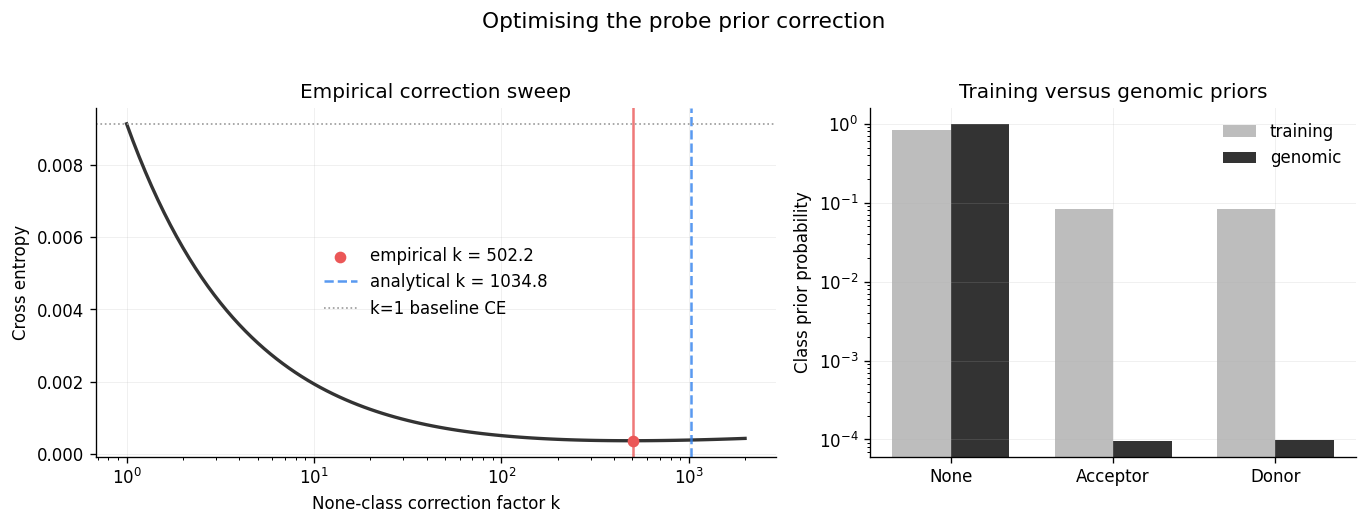

In [9]:
def plot_correction_optimisation(correction_path=correction_json):
    with open(correction_path) as f:
        correction = json.load(f)

    rows = correction["empirical_sweep"]["rows"]
    k = np.array([r["k"] for r in rows], dtype=float)
    ce = np.array([r["cross_entropy"] for r in rows], dtype=float)

    best_k = float(correction["empirical_sweep"]["best_k"])
    analytical_k = float(correction["analytical"]["analytical_k"])
    baseline_ce = float(correction["empirical_sweep"]["baseline_k1_cross_entropy"])

    real_dist = correction["analytical"]["real_distribution"]
    train_dist = correction["analytical"]["training_distribution"]
    classes = ["none", "acc", "don"]
    real = np.array([real_dist[f"p_{c}"] for c in classes])
    train = np.array([train_dist[f"p_{c}"] for c in classes])

    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2), gridspec_kw={"width_ratios": [1.4, 1]})

    ax = axes[0]
    ax.plot(k, ce, color="#333333", lw=2)
    ax.scatter([best_k], [ce[np.argmin(np.abs(k - best_k))]], color=DON_COLOR, zorder=5, label=f"empirical k = {best_k:.1f}")
    ax.axvline(best_k, color=DON_COLOR, lw=1.5, alpha=0.8)
    ax.axvline(analytical_k, color=ACC_COLOR, lw=1.5, ls="--", alpha=0.8, label=f"analytical k = {analytical_k:.1f}")
    ax.axhline(baseline_ce, color="#999999", lw=1, ls=":", label="k=1 baseline CE")
    ax.set_xscale("log")
    ax.set_xlabel("None-class correction factor k")
    ax.set_ylabel("Cross entropy")
    ax.set_title("Empirical correction sweep")
    ax.legend(frameon=False)

    ax = axes[1]
    x = np.arange(len(classes))
    width = 0.36
    ax.bar(x - width/2, train, width, label="training", color="#bdbdbd")
    ax.bar(x + width/2, real, width, label="genomic", color="#333333")
    ax.set_yscale("log")
    ax.set_xticks(x, ["None", "Acceptor", "Donor"])
    ax.set_ylabel("Class prior probability")
    ax.set_title("Training versus genomic priors")
    ax.legend(frameon=False)

    fig.suptitle("Optimising the probe prior correction", y=1.03, fontsize=13)
    fig.tight_layout()
    return fig, correction

fig, correction = plot_correction_optimisation()
save_figure(fig, "figure_correction_optimisation")
plt.show()

## 2. Example sequence and model runs

This example sequence is used for the correction trace figure and the SpliceAI comparison. Replace `input_sequence` with a gene or region of interest for the final manuscript figure if needed.

In [10]:
input_sequence = """
GGTGCCCGTCAGTGGGCAGAGCGCACATCGCCCACAGTCCCCGAGAAGTTGGGGGGAGGGGTCGGCAATTGAACCGGTGCCTAGAGAAGGTGGCGCGGGGTAAACTGGGAAAGTGATGTCGTGTACTGGCTCCGCCTTTTTCCCGAGGGTGGGGGAGAACCGTATATAAGTGCAGTAGTCGCCGTGAACGTTCTTTTTCGCAACGGGTTTGCCGCCAGAACACAGGTAAGTGCCGTGTGTGGTTCCCGCGGGCCTGGCCTCTTTACGGGTTATGGCCCTTGCGTGCCTTGAATTACTTCCACGCCCCTGGCTGCAGTACGTGATTCTTGATCCCGAGCTTCGGGTTGGAAGTGGGTGGGAGAGTTCGAGGCCTTGCGCTTAAGGAGCCCCTTCGCCTCGTGCTTGAGTTGAGGCCTGGCTTGGGCGCTGGGGCCGCCGCGTGCGAATCTGGTGGCACCTTCGCGCCTGTCTCGCTGCTTTCGATAAGTCTCTAGCCATTTAAAATTTTTGATGACCTGCTGCGACGCTTTTTTTCTGGCAAGATAGTCTTGTAAATGCGGGCCAAGATCTGCACACTGGTATTTCGGTTTTTGGGGCCGCGGGCGGCGACGGGGCCCGTGCGTCCCAGCGCACATGTTCGGCGAGGCGGGGCCTGCGAGCGCGGCCACCGAGAATCGGACGGGGGTAGTCTCAAGCTGGCCGGCCTGCTCTGGTGCCTGGCCTCGCGCCGCCGTGTATCGCCCCGCCCTGGGCGGCAAGGCTGGCCCGGTCGGCACCAGTTGCGTGAGCGGAAAGATGGCCGCTTCCCGGCCCTGCTGCAGGGAGCTCAAAATGGAGGACGCGGCGCTCGGGAGAGCGGGCGGGTGAGTCACCCACACAAAGGAAAAGGGCCTTTCCGTCCTCAGCCGTCGCTTCATGTGACTCCACGGAGTACCGGGCGCCGTCCAGGCACCTCGATTAGTTCTCGAGCTTTTGGAGTACGTCGTCTTTAGGTTGGGGGGAGGGGTTTTATGCGATGGAGTTTCCCCACACTGAGTGGGTGGAGACTGAAGTTAGGCCAGCTTGGCACTTGATGTAATTCTCCTTGGAATTTGCCCTTTTTGAGTTTGGATCTTGGTTCATTCTCAAGCCTCAGACAGTGGTTCAAAGTTTTTTTCTTCCATTTCAGGTGTCGTGAGAGCTCGTTTAGTGAACCGTCAGATCGCCTGGAGACGCCATCCACGCTGTTTTGACCTCCATAGAAGAATCTTTGTCGATCCTACCATCCACTCGACACACCCGCCAGCGGCCGCTTCTTGGTGCCAGCTTATCAGCCACCATGGTGAGCAAGGGCGAGGAGCTGTTCACCGGGGTGGTGCCCATCCTGGTCGAGCTGGACGGCGACGTAAACGGCCACAAGTTCAGCGTCCGCGGCGAGGGCGAGGGCGATGCCACCAACGGCAAGCTGACCCTGAAGTTCATCTGCACCACCGGCAAGCTGCCCGTGCCCTGGCCCACCCTCGTGACCACCTTAGGCTACGGCGTGGCCTGCTTCGCCCGCTACCCCGACCACATGAAGCAGCACGACTTCTTCAAGTCCGCCATGCCCGAAGGCTACGTCCAGGAGCGCACCATCTCTTTCAAGGACGACGGTACCTACAAGACCCGCGCCGAGGTGAAGTTCGAGGGCGACACCCTGGTGAACCGCATCGTGCTGAAGGGCATCGACTTCAAGGAGGACGGCAACATCCTGGGGCACAAGCTGGAGTACAACTTCAACAGCCACAAGGTCTATATCACGGCCGACAAGCAGAAGAACGGCATCAAGGCTAACTTCAAGACCCGCCACAACGTTGAGGACGGCGGCGTGCAGCTCGCCGACCACTACCAGCAGAACACCCCCATCGGCGACGGCCCCGTGCTGCTGCCCGACAACCACTACCTGAGCCATCAGTCCAAACTGAGCAAAGACCCCAACGAGAAGCGCGATCACATGGTCCTGAAGGAGAGGGTGACCGCCGCCGGGATTACACATGACATGGATGAACTATATAAATAATTAATGCGCGTCCTGGTAAGTTGACGACTTTTCCCTTTGGGATAATGGGGCGGGGACGGGGAAACTATGGACTAACTAACCATTTCTCTTTTTCTGTGTGTGTGTGTGAAGTGTGTGTGTGTGTGTGCGGACGCCGATGAACGACGACGACGTCCACATATAATGATATGTTCCCTCCAGGATTCGCGGAAACGCGTACATCCAGCTGACGAGTCCCAAATAGGACGAAACGCGCATTAACGCAGGCCTCTGCTAGCTTGACTGACTGAGATACAGCGTACCTTCAGCTCACGCGGCCGCTTTCTCCGCGATCCAGACATGATAAGATACATTGATGAGTTTGGACAAACCAAAACTAG
""".replace("\n", "").upper()

len(input_sequence)

2397

## 3. Figure: effect of correction value on prediction traces

This figure runs biPangolin once with `correction_k=1.0`, then applies different None-class correction values post hoc. Because the correction only rescales the three probe probabilities, this gives the same probe traces as rerunning the model with each `correction_k`, without wasting compute.

biPangolin: 3 model+probe pairs ready on mps
saved paper_figures/figure_correction_value_traces.svg and paper_figures/figure_correction_value_traces.png


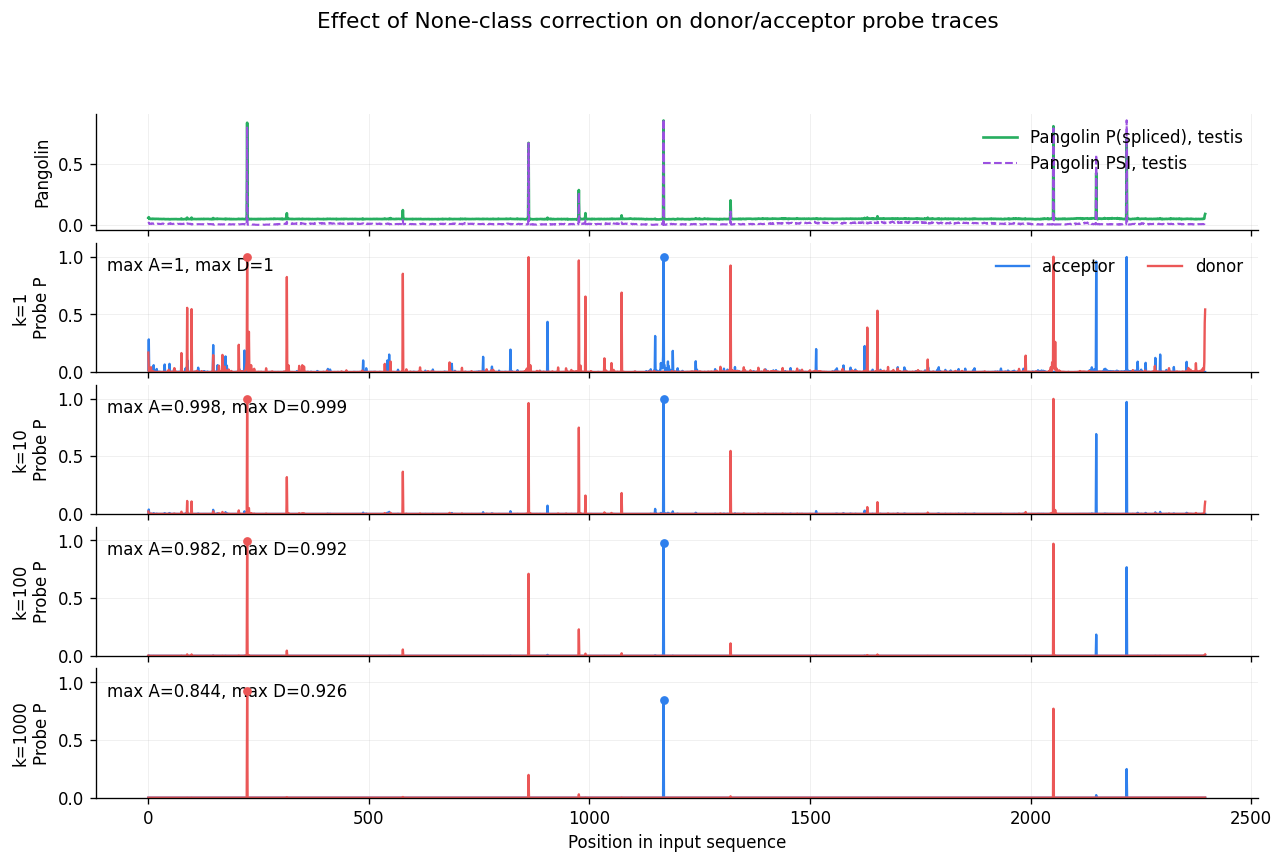

In [11]:
def apply_probe_correction(result, k):
    """Apply None-class correction k to an existing BiPangolinResult's probe tracks."""
    probs = np.stack([
        tensor_to_numpy(result.probe_none),
        tensor_to_numpy(result.probe_acceptor),
        tensor_to_numpy(result.probe_donor),
    ], axis=0).astype(float)
    probs[0] *= float(k)
    probs /= np.clip(probs.sum(axis=0, keepdims=True), 1e-12, None)
    return {
        "none": probs[0],
        "acceptor": probs[1],
        "donor": probs[2],
    }

def plot_correction_value_traces(raw_result, correction_values=(1, 10, 100, 1000), start=0, end=None):
    if end is None:
        end = len(raw_result)
    x = np.arange(start, end)

    pangolin_p = tensor_to_numpy(raw_result.pangolin_prob)[0, start:end]
    pangolin_psi = tensor_to_numpy(raw_result.pangolin_psi)[0, start:end]
    tissue = raw_result.tissues[0]

    corrected = {k: apply_probe_correction(raw_result, k) for k in correction_values}
    shared_ymax = max(
        max(corrected[k]["acceptor"][start:end].max(), corrected[k]["donor"][start:end].max())
        for k in correction_values
    )
    shared_ymax = max(0.01, shared_ymax * 1.12)

    fig, axes = plt.subplots(
        len(correction_values) + 1,
        1,
        figsize=(12.5, 2.0 + 1.35 * len(correction_values)),
        sharex=True,
        gridspec_kw={"height_ratios": [0.9] + [1] * len(correction_values), "hspace": 0.10},
    )

    ax = axes[0]
    ax.plot(x, pangolin_p, color=PANGOLIN_COLOR, lw=1.6, label=f"Pangolin P(spliced), {tissue}")
    ax.plot(x, pangolin_psi, color=PSI_COLOR, lw=1.25, ls="--", label=f"Pangolin PSI, {tissue}")
    ax.set_ylabel("Pangolin")
    ax.legend(frameon=False, loc="upper right")

    for ax, k in zip(axes[1:], correction_values):
        acc = corrected[k]["acceptor"][start:end]
        don = corrected[k]["donor"][start:end]
        ax.fill_between(x, acc, color=ACC_COLOR, alpha=0.18, lw=0)
        ax.plot(x, acc, color=ACC_COLOR, lw=1.4, label="acceptor")
        ax.fill_between(x, don, color=DON_COLOR, alpha=0.18, lw=0)
        ax.plot(x, don, color=DON_COLOR, lw=1.4, label="donor")
        ax.set_ylabel(f"k={k}\nProbe P")
        ax.set_ylim(0, shared_ymax)

        acc_peak = int(np.argmax(acc)) + start
        don_peak = int(np.argmax(don)) + start
        ax.scatter([acc_peak], [corrected[k]["acceptor"][acc_peak]], color=ACC_COLOR, s=18, zorder=4)
        ax.scatter([don_peak], [corrected[k]["donor"][don_peak]], color=DON_COLOR, s=18, zorder=4)
        ax.text(0.01, 0.78, f"max A={acc.max():.3g}, max D={don.max():.3g}", transform=ax.transAxes)

    axes[1].legend(frameon=False, loc="upper right", ncols=2)
    axes[-1].set_xlabel("Position in input sequence")
    fig.suptitle("Effect of None-class correction on donor/acceptor probe traces", y=0.995, fontsize=13)
    return fig

# Raw / uncorrected probe probabilities. Pangolin P and PSI are unchanged by k.
raw_runner = BiPangolinRunner(tissue="testis", correction_k=1.0)
raw_result = raw_runner.score_sequence(input_sequence)

fig = plot_correction_value_traces(raw_result, correction_values=(1, 10, 100, 1000))
save_figure(fig, "figure_correction_value_traces")
plt.show()

In [ ]:
# Use one tissue for simple example plots. Use tissue="all_tissues" for all tissue rows.
runner = BiPangolinRunner(tissue="testis")
bp_result = runner.score_sequence(input_sequence)
bp_result

In [ ]:
def load_spliceai_models():
    from pkg_resources import resource_filename
    from tensorflow.keras.models import load_model

    paths = (f"models/spliceai{x}.h5" for x in range(1, 6))
    return [load_model(resource_filename("spliceai", path)) for path in paths]

def get_spliceai_probs(input_sequence, models, context=10000):
    from spliceai.utils import one_hot_encode as spliceai_one_hot_encode

    x = spliceai_one_hot_encode("N" * (context // 2) + input_sequence + "N" * (context // 2))[None, :]
    y = np.mean([model.predict(x, verbose=0) for model in models], axis=0)
    acceptor_prob = y[0, :, 1]
    donor_prob = y[0, :, 2]
    return acceptor_prob, donor_prob, np.arange(len(acceptor_prob))

try:
    spliceai_models = load_spliceai_models()
    spliceai_acceptor, spliceai_donor, nt_pos = get_spliceai_probs(input_sequence, spliceai_models)
except Exception as e:
    spliceai_models = None
    spliceai_acceptor = spliceai_donor = nt_pos = None
    warnings.warn(f"SpliceAI could not be loaded/run: {e}")

## 4. Figure: benchmark against SpliceAI itself

This plot compares SpliceAI donor/acceptor probabilities with the biPangolin probe donor/acceptor probabilities on the same input sequence.

In [ ]:
def top_peak_positions(track, n=5, min_value=0.01):
    track = np.asarray(track)
    order = np.argsort(track)[::-1]
    keep = [i for i in order if track[i] >= min_value]
    return keep[:n]

def plot_spliceai_bipangolin_tracks(result, spliceai_acceptor=None, spliceai_donor=None, start=0, end=None):
    if end is None:
        end = len(result)
    x = np.arange(start, end)

    bp_acc = tensor_to_numpy(result.probe_acceptor)[start:end]
    bp_don = tensor_to_numpy(result.probe_donor)[start:end]
    pangolin_p = tensor_to_numpy(result.pangolin_prob)[0, start:end]
    pangolin_psi = tensor_to_numpy(result.pangolin_psi)[0, start:end]
    tissue = result.tissues[0]

    nrows = 3 if spliceai_acceptor is not None else 2
    fig, axes = plt.subplots(nrows, 1, figsize=(12, 7.2), sharex=True, gridspec_kw={"hspace": 0.12})
    if nrows == 2:
        axes = np.asarray(axes)

    row = 0
    if spliceai_acceptor is not None:
        ax = axes[row]
        ax.plot(x, spliceai_acceptor[start:end], color=ACC_COLOR, lw=1.6, label="SpliceAI acceptor")
        ax.plot(x, spliceai_donor[start:end], color=DON_COLOR, lw=1.6, label="SpliceAI donor")
        ax.set_ylabel("SpliceAI P")
        ax.legend(frameon=False, loc="upper right")
        row += 1

    ax = axes[row]
    ax.plot(x, bp_acc, color=ACC_COLOR, lw=1.6, label="biPangolin acceptor probe")
    ax.plot(x, bp_don, color=DON_COLOR, lw=1.6, label="biPangolin donor probe")
    ax.set_ylabel("Probe P")
    ax.legend(frameon=False, loc="upper right")
    row += 1

    ax = axes[row]
    ax.plot(x, pangolin_p, color=PANGOLIN_COLOR, lw=1.6, label=f"Pangolin P(spliced), {tissue}")
    ax.plot(x, pangolin_psi, color=PSI_COLOR, lw=1.4, ls="--", label=f"Pangolin PSI, {tissue}")
    ax.set_ylabel("Pangolin")
    ax.set_xlabel("Position in input sequence")
    ax.legend(frameon=False, loc="upper right")

    fig.suptitle("biPangolin and SpliceAI predictions on the same sequence", y=0.99, fontsize=13)
    return fig

fig = plot_spliceai_bipangolin_tracks(bp_result, spliceai_acceptor, spliceai_donor)
save_figure(fig, "figure_spliceai_bipangolin_tracks")
plt.show()

In [ ]:
def plot_spliceai_bipangolin_scatter(result, spliceai_acceptor, spliceai_donor):
    bp_acc = tensor_to_numpy(result.probe_acceptor)
    bp_don = tensor_to_numpy(result.probe_donor)

    fig, axes = plt.subplots(1, 2, figsize=(9, 4), sharex=False, sharey=False)
    pairs = [
        (spliceai_acceptor, bp_acc, "Acceptor", ACC_COLOR),
        (spliceai_donor, bp_don, "Donor", DON_COLOR),
    ]
    for ax, (x, y, label, color) in zip(axes, pairs):
        ax.scatter(x, y, s=12, alpha=0.35, color=color, edgecolor="none")
        r = np.corrcoef(x, y)[0, 1]
        ax.text(0.04, 0.92, f"r = {r:.3f}", transform=ax.transAxes)
        ax.set_xlabel(f"SpliceAI {label.lower()} P")
        ax.set_ylabel(f"biPangolin {label.lower()} probe P")
        ax.set_title(label)
        ax.set_xlim(-0.01, max(0.05, np.nanmax(x) * 1.08))
        ax.set_ylim(-0.01, max(0.05, np.nanmax(y) * 1.08))

    fig.suptitle("Position-wise agreement with SpliceAI", y=1.03, fontsize=13)
    fig.tight_layout()
    return fig

if spliceai_acceptor is not None:
    fig = plot_spliceai_bipangolin_scatter(bp_result, spliceai_acceptor, spliceai_donor)
    save_figure(fig, "figure_spliceai_bipangolin_scatter")
    plt.show()
else:
    print("Skipping scatter: SpliceAI outputs are unavailable.")

## 5. Figure: true donor versus true acceptor discrimination

This section expects a labelled benchmark table. Use held-out chromosomes for the manuscript.

Required columns:

- `sequence`: sequence scored by biPangolin
- `position`: 0-based position within `sequence`
- `label`: `donor` or `acceptor`

Optional columns such as `chrom`, `genomic_pos`, or `motif` will be kept for labelling.

In [ ]:
# Set this to your held-out benchmark CSV/TSV when available.
# Example schema: sequence,position,label,chrom,genomic_pos,motif
benchmark_sites_path = None

In [ ]:
def load_benchmark_sites(path):
    if pd is None:
        raise ImportError("Install pandas or load your benchmark table manually.")
    path = Path(path)
    if path.suffix.lower() in {".tsv", ".txt"}:
        return pd.read_csv(path, sep="\t")
    return pd.read_csv(path)

def score_labelled_sites(sites, runner):
    rows = []
    cache = {}
    for idx, row in sites.iterrows():
        seq = str(row["sequence"]).upper()
        pos = int(row["position"])
        if seq not in cache:
            cache[seq] = score_sequence_or_long_sequence(runner, seq)
        result = cache[seq]
        p_none = float(result.probe_none[pos])
        p_acc = float(result.probe_acceptor[pos])
        p_don = float(result.probe_donor[pos])
        pred_idx = int(np.argmax([p_none, p_acc, p_don]))
        pred = ["none", "acceptor", "donor"][pred_idx]
        out = dict(row)
        out.update({"p_none": p_none, "p_acceptor": p_acc, "p_donor": p_don, "pred": pred})
        rows.append(out)
    return pd.DataFrame(rows)

def plot_donor_acceptor_discrimination(scored):
    true = scored["label"].str.lower().to_numpy()
    colors = np.where(true == "donor", DON_COLOR, ACC_COLOR)

    fig, axes = plt.subplots(1, 2, figsize=(9.5, 4.2), gridspec_kw={"width_ratios": [1.2, 1]})

    ax = axes[0]
    ax.scatter(scored["p_acceptor"], scored["p_donor"], c=colors, s=24, alpha=0.75, edgecolor="white", linewidth=0.3)
    ax.plot([0, 1], [0, 1], color="#888888", lw=1, ls="--")
    ax.set_xlabel("Probe P(acceptor)")
    ax.set_ylabel("Probe P(donor)")
    ax.set_title("True splice-site discrimination")
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)

    labels = ["acceptor", "donor"]
    cm = np.zeros((2, 2), dtype=int)
    for i, t in enumerate(labels):
        for j, p in enumerate(labels):
            cm[i, j] = int(((scored["label"].str.lower() == t) & (scored["pred"] == p)).sum())

    ax = axes[1]
    im = ax.imshow(cm, cmap="Greys")
    ax.set_xticks([0, 1], ["pred A", "pred D"])
    ax.set_yticks([0, 1], ["true A", "true D"])
    ax.set_title("Confusion matrix")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, str(cm[i, j]), ha="center", va="center", color="black")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    acc = (scored["label"].str.lower().str[:1] == scored["pred"].str[:1]).mean()
    fig.suptitle(f"Donor versus acceptor classification accuracy = {acc:.3%}", y=1.02, fontsize=13)
    fig.tight_layout()
    return fig

if benchmark_sites_path:
    sites = load_benchmark_sites(benchmark_sites_path)
    scored_sites = score_labelled_sites(sites, runner)
    fig = plot_donor_acceptor_discrimination(scored_sites)
    save_figure(fig, "figure_true_donor_acceptor_discrimination")
    plt.show()
else:
    print("Set benchmark_sites_path to make the true donor/acceptor discrimination figure.")

## 6. Figure: Pangolin PSI / P(spliced) versus probe confidence

This figure asks whether the probe is confident specifically where Pangolin reports strong splicing signal.

In [ ]:
def plot_pangolin_vs_probe_confidence(result):
    probe_none = tensor_to_numpy(result.probe_none)
    probe_acc = tensor_to_numpy(result.probe_acceptor)
    probe_don = tensor_to_numpy(result.probe_donor)
    probe_conf = np.maximum(probe_acc, probe_don)
    probe_label_idx = np.stack([probe_none, probe_acc, probe_don], axis=0).argmax(axis=0)
    color_map = np.array([NONE_COLOR, ACC_COLOR, DON_COLOR])
    colors = color_map[probe_label_idx]

    pangolin_prob = tensor_to_numpy(result.pangolin_prob)
    pangolin_psi = tensor_to_numpy(result.pangolin_psi)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4.2), sharex=True)
    for tissue_idx, tissue in enumerate(result.tissues):
        axes[0].scatter(probe_conf, pangolin_prob[tissue_idx], s=10, alpha=0.28, c=colors, edgecolor="none", label=tissue if tissue_idx == 0 else None)
        axes[1].scatter(probe_conf, pangolin_psi[tissue_idx], s=10, alpha=0.28, c=colors, edgecolor="none")

    axes[0].set_ylabel("Pangolin P(spliced)")
    axes[1].set_ylabel("Pangolin PSI")
    for ax in axes:
        ax.set_xlabel("Probe confidence max[P(acceptor), P(donor)]")
        ax.set_xlim(-0.01, max(0.05, probe_conf.max() * 1.08))

    handles = [
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=NONE_COLOR, label="none", markersize=7),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=ACC_COLOR, label="acceptor-routed", markersize=7),
        plt.Line2D([0], [0], marker="o", color="w", markerfacecolor=DON_COLOR, label="donor-routed", markersize=7),
    ]
    axes[1].legend(handles=handles, frameon=False, loc="upper right")
    fig.suptitle("Pangolin signal versus biPangolin probe confidence", y=1.03, fontsize=13)
    fig.tight_layout()
    return fig

fig = plot_pangolin_vs_probe_confidence(bp_result)
save_figure(fig, "figure_pangolin_vs_probe_confidence")
plt.show()

## 7. Optional: export the 4-track-per-tissue matrix

Channel order:

0. donor PSI
1. donor P(spliced)
2. acceptor PSI
3. acceptor P(spliced)

In [ ]:
four_track = bp_result.four_track_per_tissue().detach().cpu().numpy()
np.save(FIG_DIR / "example_four_track_per_tissue.npy", four_track)
four_track.shape